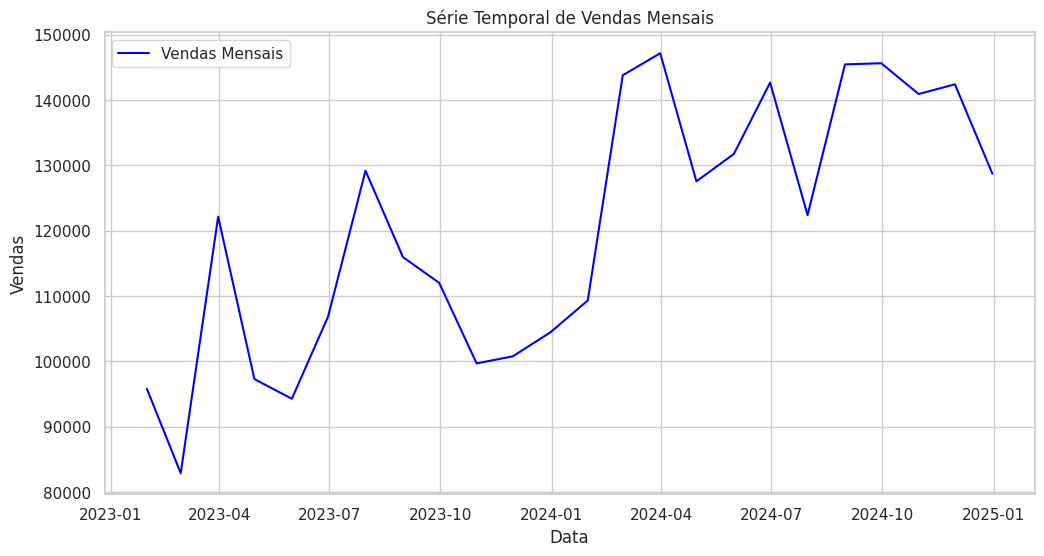

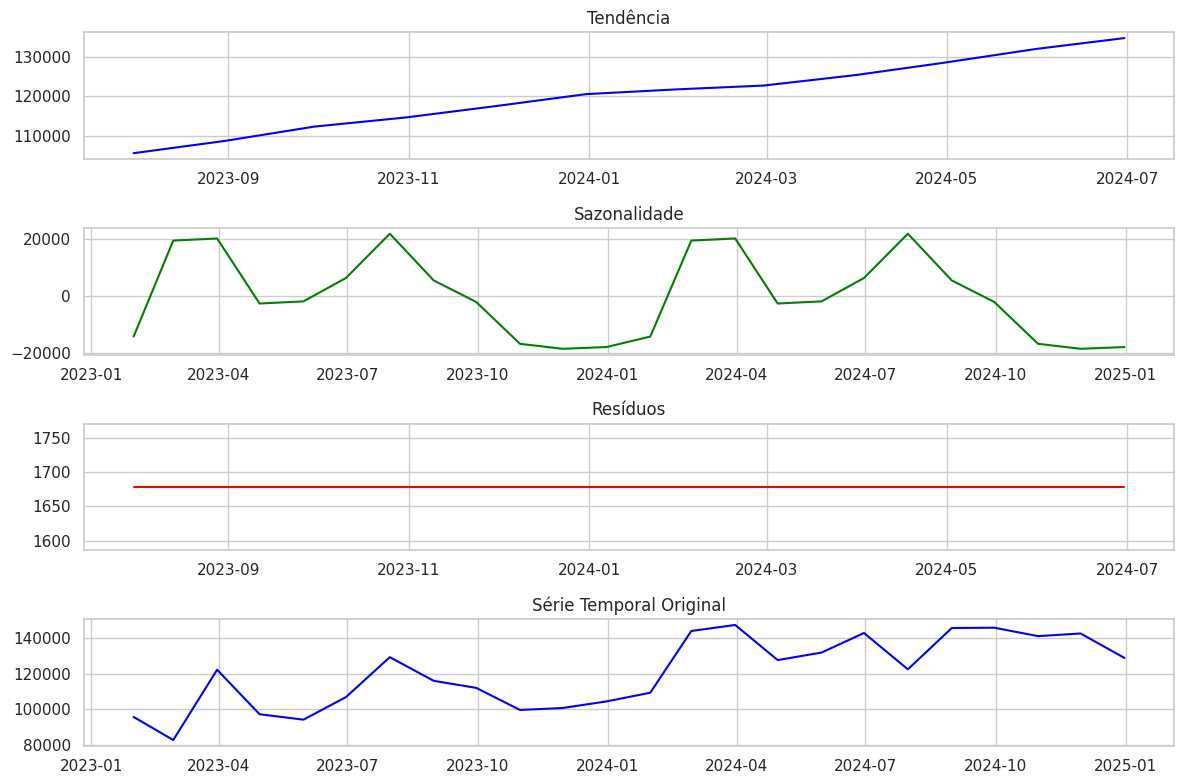

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Criando dados fictícios de vendas ao longo do tempo
np.random.seed(42)
meses = pd.date_range(start='2023-01-01', periods=24, freq='M')
vendas = np.random.randint(80000, 120000, size=24) + np.arange(24) * 2000

df = pd.DataFrame({'Mes': meses, 'Vendas': vendas})

# Configurando o índice como a coluna de datas
df.set_index('Mes', inplace=True)

# Visualizando a série temporal
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Vendas'], label='Vendas Mensais', color='blue')
plt.title('Série Temporal de Vendas Mensais')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.show()

# Decompondo a série temporal em tendência, sazonalidade e resíduos
decomposicao = sm.tsa.seasonal_decompose(df['Vendas'], model='additive', period=12)

# Visualizando as componentes da decomposição
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(decomposicao.trend, label='Tendência', color='blue')
plt.title('Tendência')

plt.subplot(4, 1, 2)
plt.plot(decomposicao.seasonal, label='Sazonalidade', color='green')
plt.title('Sazonalidade')

plt.subplot(4, 1, 3)
plt.plot(decomposicao.resid, label='Resíduos', color='red')
plt.title('Resíduos')

plt.subplot(4, 1, 4)
plt.plot(df['Vendas'], label='Vendas Mensais', color='blue')
plt.title('Série Temporal Original')

plt.tight_layout()
plt.show()

In [23]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Criando uma instância do analisador de sentimentos VADER
analisador_sentimentos = SentimentIntensityAnalyzer()

# Exemplos de textos (substitua esses textos pelos seus próprios dados)
textos = [
    "Estou muito feliz com o novo produto!",
    "O serviço ao cliente foi terrível.",
    "A entrega foi atrasada, estou insatisfeito.",
    "Adoro a qualidade dos produtos, mas o preço é alto."
]

# Analisando o sentimento de cada texto
for texto in textos:
    pontuacao = analisador_sentimentos.polarity_scores(texto)
    sentimento = 'Positivo' if pontuacao['compound'] >= 0 else 'Negativo'

    print(f"Texto: {texto}")
    print(f"Pontuação de Sentimento: {pontuacao['compound']:.2f} (Sentimento: {sentimento})")
    print("="*50)

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Texto: Estou muito feliz com o novo produto!
Sentimento: POSITIVE (Confiança: 0.92)
Texto: O serviço ao cliente foi terrível.
Sentimento: POSITIVE (Confiança: 0.94)
Texto: A entrega foi atrasada, estou insatisfeito.
Sentimento: POSITIVE (Confiança: 0.78)
Texto: Adoro a qualidade dos produtos, mas o preço é alto.
Sentimento: POSITIVE (Confiança: 0.97)


In [26]:
import scikit-surprise
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Criando um conjunto de dados fictício
dados_ficticios = [
    ('1', 'A', 4.5),
    ('1', 'B', 3.5),
    ('1', 'C', 5),
    ('2', 'A', 4),
    ('2', 'B', 5),
    ('2', 'C', 3),
    ('3', 'A', 2),
    ('3', 'B', 4),
    ('3', 'C', 3.5),
    ('4', 'A', 5),
    ('4', 'B', 4),
    ('4', 'C', 2),
    ('5', 'A', 3),
    ('5', 'B', 3.5),
    ('5', 'C', 4)
]

# Convertendo os dados para um formato suportado pelo Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(pd.DataFrame(dados_ficticios, columns=['userID', 'itemID', 'rating']), reader)

# Dividindo o conjunto de dados em treinamento e teste
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Criando um modelo SVD (Singular Value Decomposition)
modelo = SVD()

# Treinando o modelo
modelo.fit(trainset)

# Fazendo previsões no conjunto de teste
previsoes = modelo.test(testset)

# Avaliando a precisão do modelo
precisao = accuracy.rmse(previsoes)
print(f'Raiz do Erro Quadrático Médio (RMSE): {precisao:.4f}')

# Fazendo recomendações para um usuário específico (por exemplo, usuário com ID 1)
usuario_id = '1'
itens_nao_avaliados = [item for item in trainset.all_items() if usuario_id not in trainset.ur[item]]
recomendacoes = [modelo.predict(usuario_id, item) for item in itens_nao_avaliados]

# Ordenando as recomendações por pontuação prevista
recomendacoes.sort(key=lambda x: x.est, reverse=True)

# Exibindo as top 5 recomendações
print(f'Recomendações para o Usuário {usuario_id}:')
for i, recomendacao in enumerate(recomendacoes[:5], 1):import
    print(f"{i}. Item ID: {recomendacao.iid} - Pontuação Prevista: {recomendacao.est:.2f}")

SyntaxError: ignored

In [26]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Criando dados fictícios de clientes
dados_clientes = {
    'Idade': [25, 30, 35, 22, 28, 32, 45, 50, 48, 60],
    'Renda Anual (milhares)': [50, 60, 75, 40, 45, 55, 80, 90, 95, 120],
    'Pontuação de Gastos (1-100)': [75, 80, 85, 10, 20, 5, 90, 95, 100, 60]
}

df_clientes = pd.DataFrame(dados_clientes)

# Normalizando os dados
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(df_clientes)

# Aplicando o algoritmo K-Means para segmentação em 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42)
df_clientes['Segmento'] = kmeans.fit_predict(dados_normalizados)

# Visualizando os grupos
plt.scatter(df_clientes['Idade'], df_clientes['Pontuação de Gastos (1-100)'], c=df_clientes['Segmento'], cmap='viridis')
plt.xlabel('Idade')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.title('Segmentação de Clientes')
plt.show()

# Exibindo os centroides dos clusters
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroides = pd.DataFrame(centroides, columns=df_clientes.columns[:-1])
print('\nCentroides dos Clusters:')
print(df_centroides)

SyntaxError: ignored

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Carregando o conjunto de dados Spambase (disponível em https://archive.ics.uci.edu/ml/datasets/spambase)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
col_names = [f"Feature_{i}" for i in range(57)] + ['is_spam']
df = pd.read_csv(url, header=None, names=col_names)

# Separando os recursos (X) e os rótulos (y)
X = df.drop('is_spam', axis=1)
y = df['is_spam']

# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando um modelo Naive Bayes
modelo = MultinomialNB()
modelo.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
previsoes = modelo.predict(X_test)

# Avaliando o desempenho do modelo
acuracia = accuracy_score(y_test, previsoes)
matriz_confusao = confusion_matrix(y_test, previsoes)
relatorio_classificacao = classification_report(y_test, previsoes)

# Exibindo resultados
print(f'Acurácia do Modelo: {acuracia:.2f}\n')
print('Matriz de Confusão:')
print(matriz_confusao)
print('\nRelatório de Classificação:')
print(relatorio_classificacao)

Acurácia do Modelo: 0.79

Matriz de Confusão:
[[445  86]
 [111 279]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.76      0.72      0.74       390

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921



In [31]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Baixando recursos adicionais do NLTK (somente na primeira execução)
nltk.download('punkt')

# Exemplo de texto
texto = "A tokenização é um passo fundamental em processamento de linguagem natural. Ela divide um texto em palavras ou sentenças."

# Tokenização de palavras
palavras_tokenizadas = word_tokenize(texto)

# Tokenização de sentenças
sentencas_tokenizadas = sent_tokenize(texto)

# Exibindo resultados
print("Texto Original:")
print(texto)
print("\nTokenização de Palavras:")
print(palavras_tokenizadas)
print("\nTokenização de Sentenças:")
print(sentencas_tokenizadas)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Texto Original:
A tokenização é um passo fundamental em processamento de linguagem natural. Ela divide um texto em palavras ou sentenças.

Tokenização de Palavras:
['A', 'tokenização', 'é', 'um', 'passo', 'fundamental', 'em', 'processamento', 'de', 'linguagem', 'natural', '.', 'Ela', 'divide', 'um', 'texto', 'em', 'palavras', 'ou', 'sentenças', '.']

Tokenização de Sentenças:
['A tokenização é um passo fundamental em processamento de linguagem natural.', 'Ela divide um texto em palavras ou sentenças.']


In [1]:
import pandas as pd

# Criando um DataFrame com alguns dados fictícios
data = {'Nome': ['Alice', 'Bob', 'Charlie', 'David'],
        'Idade': [25, 30, 35, 40],
        'Salário': [50000, 60000, 75000, 90000]}

df = pd.DataFrame(data)

# Adicionando uma nova coluna
df['Departamento'] = ['TI', 'Vendas', 'RH', 'Marketing']

# Exibindo o DataFrame atualizado
print("DataFrame Atualizado:")
print(df)
print()

# Ordenando os dados por idade em ordem decrescente
df = df.sort_values(by='Idade', ascending=False)

# Exibindo o DataFrame ordenado
print("DataFrame Ordenado por Idade (decrescente):")
print(df)
print()

# Agrupando por departamento e calculando a média do salário em cada departamento
media_salario_por_departamento = df.groupby('Departamento')['Salário'].mean()

# Exibindo a média salarial por departamento
print("Média Salarial por Departamento:")
print(media_salario_por_departamento)

DataFrame Atualizado:
      Nome  Idade  Salário Departamento
0    Alice     25    50000           TI
1      Bob     30    60000       Vendas
2  Charlie     35    75000           RH
3    David     40    90000    Marketing

DataFrame Ordenado por Idade (decrescente):
      Nome  Idade  Salário Departamento
3    David     40    90000    Marketing
2  Charlie     35    75000           RH
1      Bob     30    60000       Vendas
0    Alice     25    50000           TI

Média Salarial por Departamento:
Departamento
Marketing    90000.0
RH           75000.0
TI           50000.0
Vendas       60000.0
Name: Salário, dtype: float64


In [2]:
import requests
from bs4 import BeautifulSoup

# URL da página que queremos fazer scraping
url = 'https://exemplo.com/noticias'

# Enviando uma solicitação para a página e obtendo o conteúdo HTML
response = requests.get(url)
html_content = response.content

# Criando um objeto BeautifulSoup para analisar o HTML
soup = BeautifulSoup(html_content, 'html.parser')

# Encontrando todas as manchetes de notícias na página
manchetes = soup.find_all('h2', class_='titulo-noticia')

# Exibindo as manchetes
print("Manchetes de Notícias:")
for manchete in manchetes:
    print(manchete.text.strip())

KeyboardInterrupt: ignored

Informações Básicas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Nome       5 non-null      object
 1   Pontuacao  5 non-null      int64 
 2   Faltas     5 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 248.0+ bytes
None

Estatísticas Descritivas:
       Pontuacao    Faltas
count   5.000000  5.000000
mean   86.600000  2.200000
std     5.458938  1.923538
min    78.000000  0.000000
25%    85.000000  1.000000
50%    88.000000  2.000000
75%    90.000000  3.000000
max    92.000000  5.000000



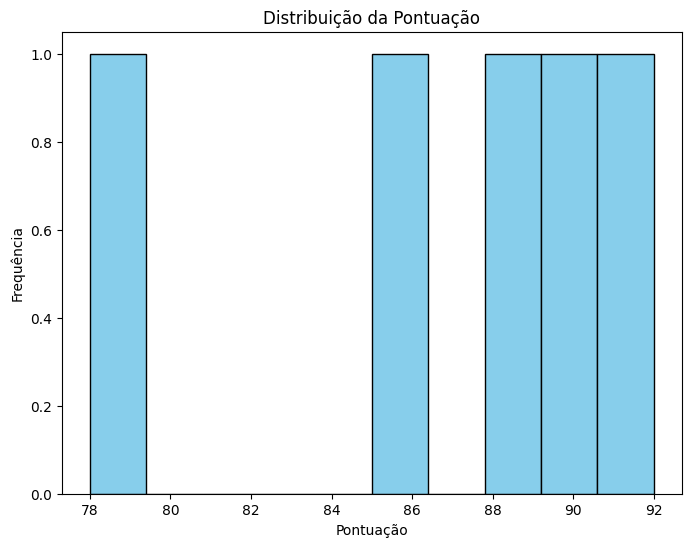

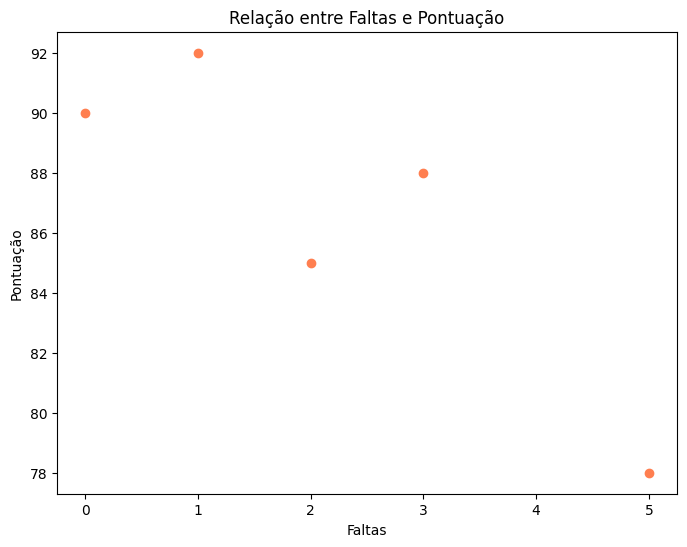

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Criando um DataFrame com dados fictícios
data = {'Nome': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
        'Pontuacao': [85, 90, 78, 92, 88],
        'Faltas': [2, 0, 5, 1, 3]}

df = pd.DataFrame(data)

# Exibindo informações básicas sobre o DataFrame
print("Informações Básicas:")
print(df.info())
print()

# Exibindo estatísticas descritivas
print("Estatísticas Descritivas:")
print(df.describe())
print()

# Visualizando a distribuição da pontuação
plt.figure(figsize=(8, 6))
plt.hist(df['Pontuacao'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribuição da Pontuação')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')
plt.show()

# Visualizando a relação entre pontuação e faltas
plt.figure(figsize=(8, 6))
plt.scatter(df['Faltas'], df['Pontuacao'], color='coral')
plt.title('Relação entre Faltas e Pontuação')
plt.xlabel('Faltas')
plt.ylabel('Pontuação')
plt.show()

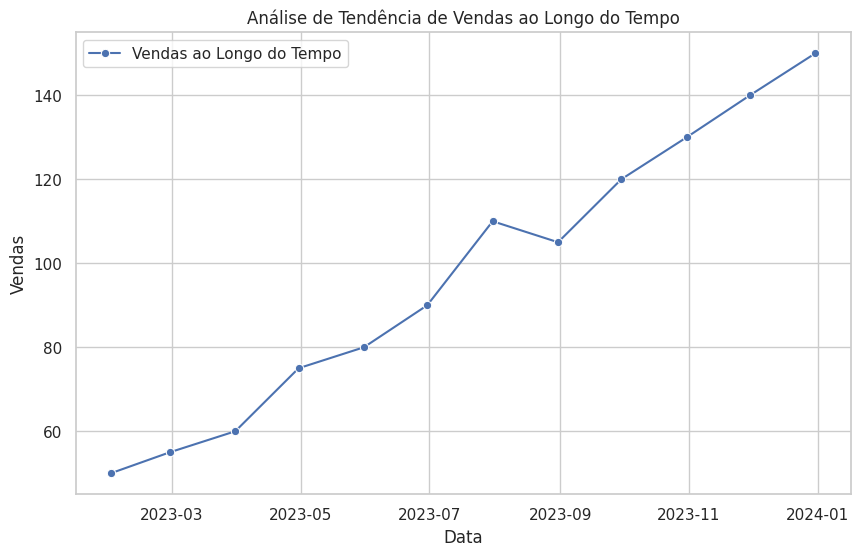

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Criando um DataFrame fictício com dados de vendas ao longo do tempo
data = {'Data': pd.date_range(start='2023-01-01', periods=12, freq='M'),
        'Vendas': [50, 55, 60, 75, 80, 90, 110, 105, 120, 130, 140, 150]}

df = pd.DataFrame(data)

# Configurando o estilo do Seaborn
sns.set(style="whitegrid")

# Criando um gráfico de linha para visualizar a tendência
plt.figure(figsize=(10, 6))
sns.lineplot(x='Data', y='Vendas', data=df, marker='o', color='b', label='Vendas ao Longo do Tempo')

# Adicionando título e rótulos aos eixos
plt.title('Análise de Tendência de Vendas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')

# Exibindo a legenda
plt.legend()

# Exibindo o gráfico
plt.show()


Vamos criar um exemplo prático na área de negócios usando Seaborn para visualizar dados relacionados a vendas e despesas ao longo do tempo. Para este exemplo, suponhamos que temos um DataFrame com informações fictícias sobre vendas e despesas mensais de uma empresa.

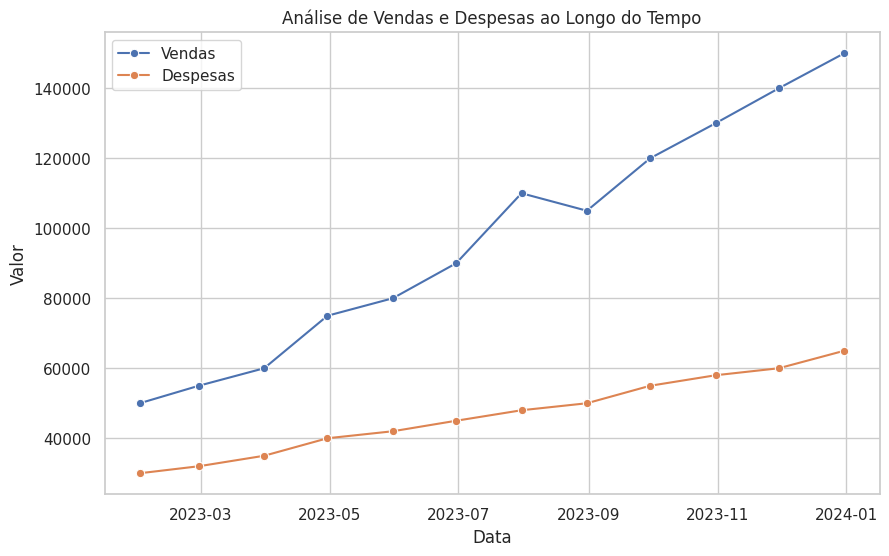

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Criando um DataFrame fictício com dados de vendas e despesas ao longo do tempo
data = {
    'Data': pd.date_range(start='2023-01-01', periods=12, freq='M'),
    'Vendas': [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000],
    'Despesas': [30000, 32000, 35000, 40000, 42000, 45000, 48000, 50000, 55000, 58000, 60000, 65000]
}

df = pd.DataFrame(data)

# Configurando o estilo do Seaborn
sns.set(style="whitegrid")

# Criando um gráfico de linhas para visualizar vendas e despesas ao longo do tempo
plt.figure(figsize=(10, 6))
sns.lineplot(x='Data', y='Vendas', data=df, marker='o', label='Vendas')
sns.lineplot(x='Data', y='Despesas', data=df, marker='o', label='Despesas')

# Adicionando título e rótulos aos eixos
plt.title('Análise de Vendas e Despesas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()

# Exibindo o gráfico
plt.show()


Vamos criar um exemplo prático na área de negócios usando Seaborn para visualizar dados relacionados a vendas e despesas ao longo do tempo. Para este exemplo, suponhamos que temos um DataFrame com informações fictícias sobre vendas e despesas mensais de uma empresa.

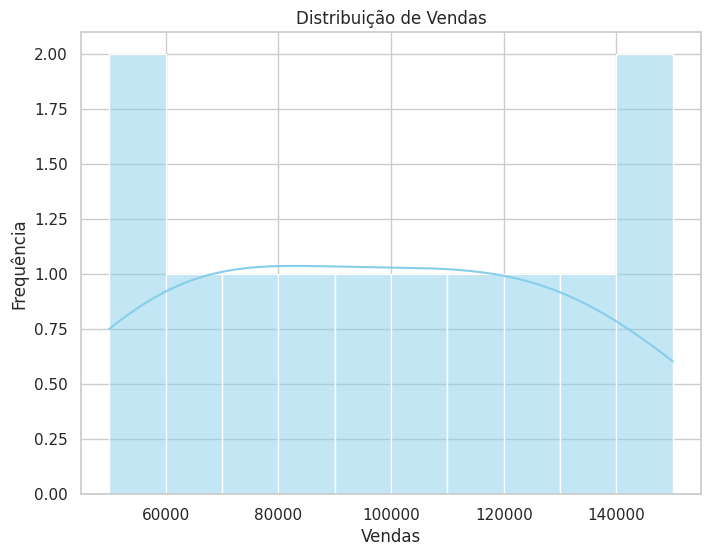

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Criando um DataFrame fictício com dados de vendas
data = {'Vendas': [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000]}
df = pd.DataFrame(data)

# Configurando o estilo do Seaborn
sns.set(style="whitegrid")

# Criando um histograma de vendas
plt.figure(figsize=(8, 6))
sns.histplot(df['Vendas'], bins=10, kde=True, color='skyblue')
plt.title('Distribuição de Vendas')
plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.show()

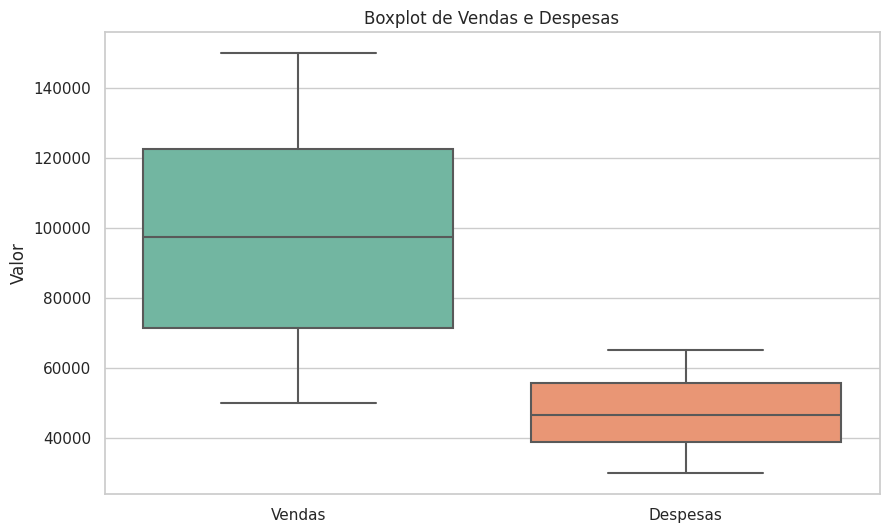

In [7]:
# Adicionando dados fictícios de despesas ao DataFrame
df['Despesas'] = [30000, 32000, 35000, 40000, 42000, 45000, 48000, 50000, 55000, 58000, 60000, 65000]

# Criando um boxplot de vendas e despesas
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Vendas', 'Despesas']], palette='Set2')
plt.title('Boxplot de Vendas e Despesas')
plt.ylabel('Valor')
plt.show()

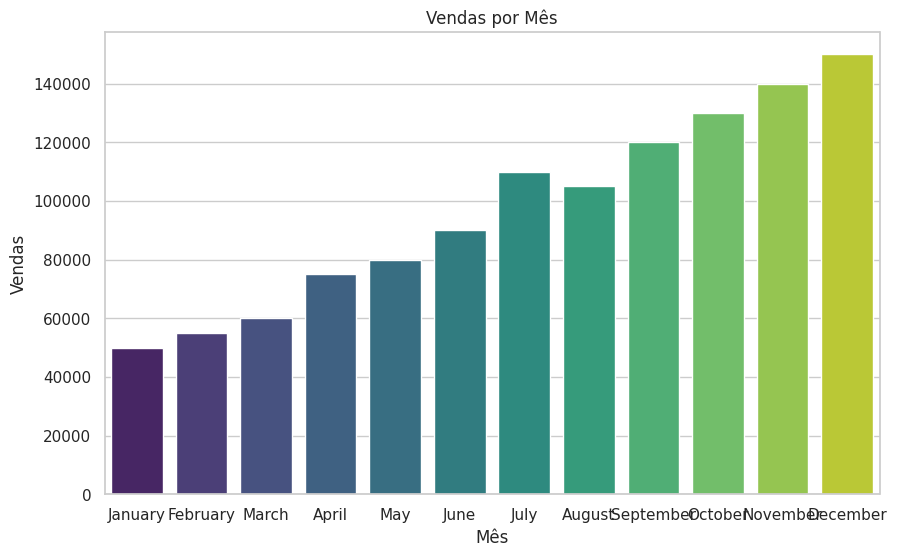

In [8]:
# Adicionando dados fictícios de mês ao DataFrame
df['Mes'] = pd.date_range(start='2023-01-01', periods=12, freq='M').month_name()

# Criando um gráfico de barras de vendas por mês
plt.figure(figsize=(10, 6))
sns.barplot(x='Mes', y='Vendas', data=df, palette='viridis')
plt.title('Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.show()

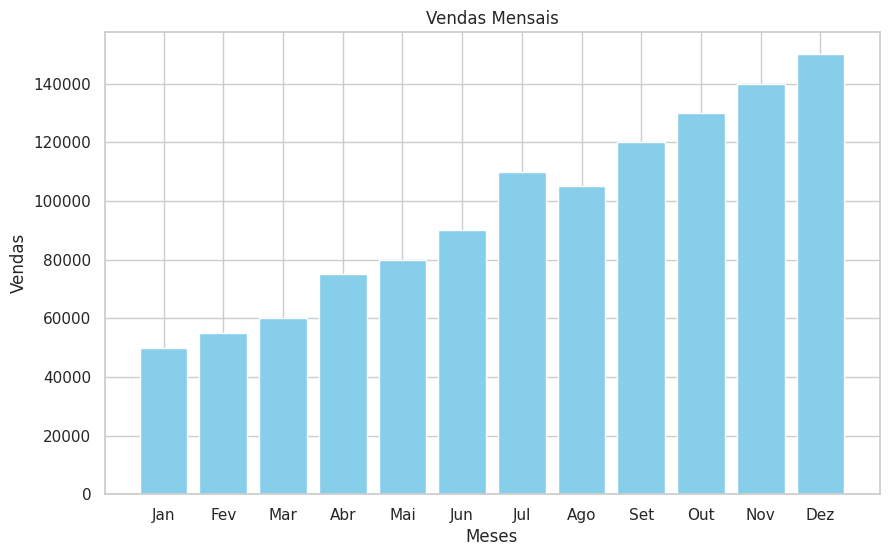

In [9]:
import matplotlib.pyplot as plt

# Dados fictícios de vendas mensais
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
vendas = [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000]

# Criando um gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(meses, vendas, color='skyblue')
plt.title('Vendas Mensais')
plt.xlabel('Meses')
plt.ylabel('Vendas')
plt.show()

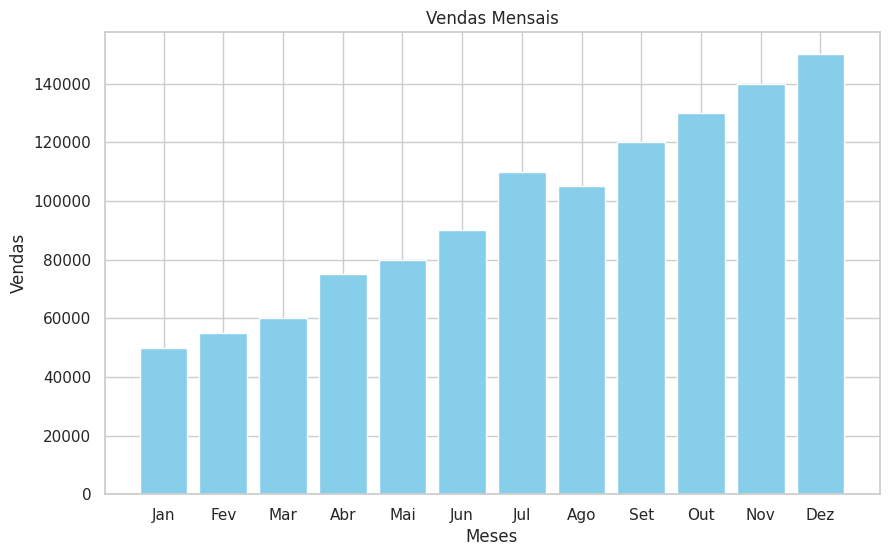

In [9]:
import matplotlib.pyplot as plt

# Dados fictícios de vendas mensais
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
vendas = [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000]

# Criando um gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(meses, vendas, color='skyblue')
plt.title('Vendas Mensais')
plt.xlabel('Meses')
plt.ylabel('Vendas')
plt.show()

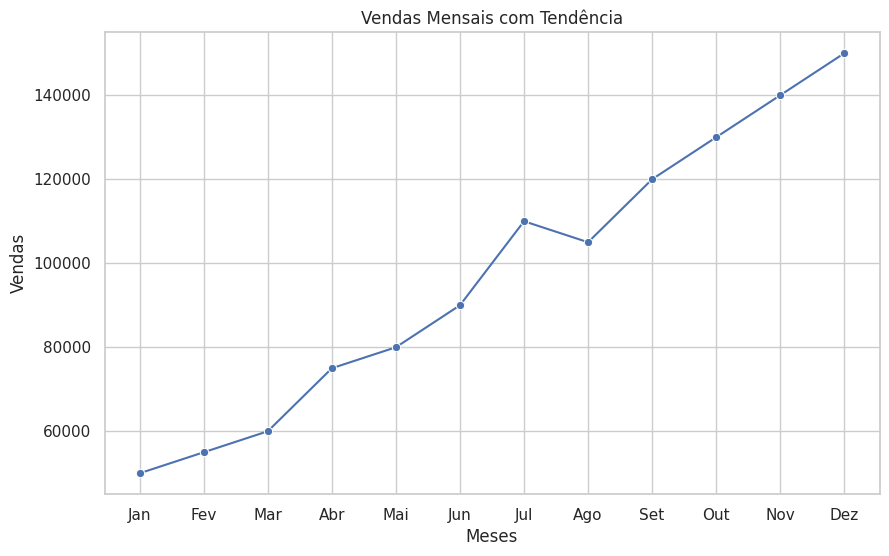

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dados fictícios de vendas mensais
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
vendas = [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000]

# Criando um DataFrame
df = pd.DataFrame({'Meses': meses, 'Vendas': vendas})

# Configurando o estilo do Seaborn
sns.set(style="whitegrid")

# Criando um gráfico de linhas com tendência
plt.figure(figsize=(10, 6))
sns.lineplot(x='Meses', y='Vendas', data=df, marker='o')
plt.title('Vendas Mensais com Tendência')
plt.xlabel('Meses')
plt.ylabel('Vendas')
plt.show()

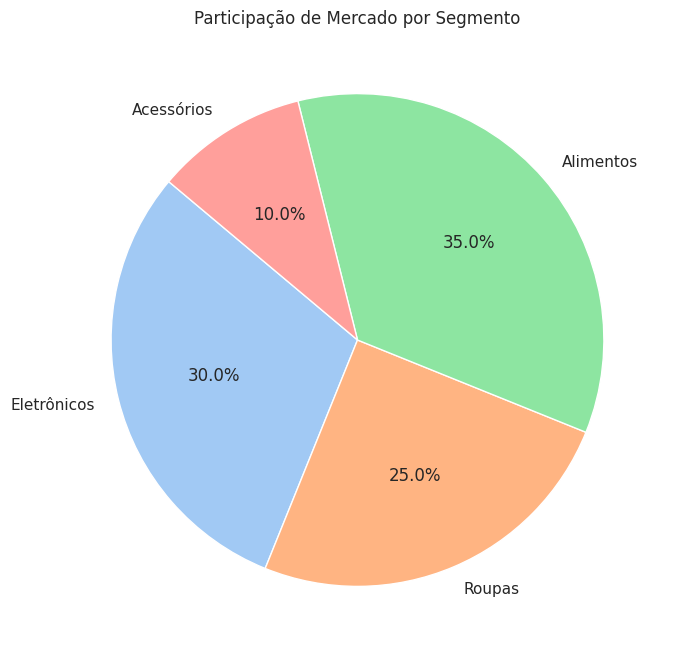

In [11]:
# Dados fictícios de participação de mercado
segmentos = ['Eletrônicos', 'Roupas', 'Alimentos', 'Acessórios']
participacao = [30, 25, 35, 10]

# Criando um gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(participacao, labels=segmentos, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Participação de Mercado por Segmento')
plt.show()

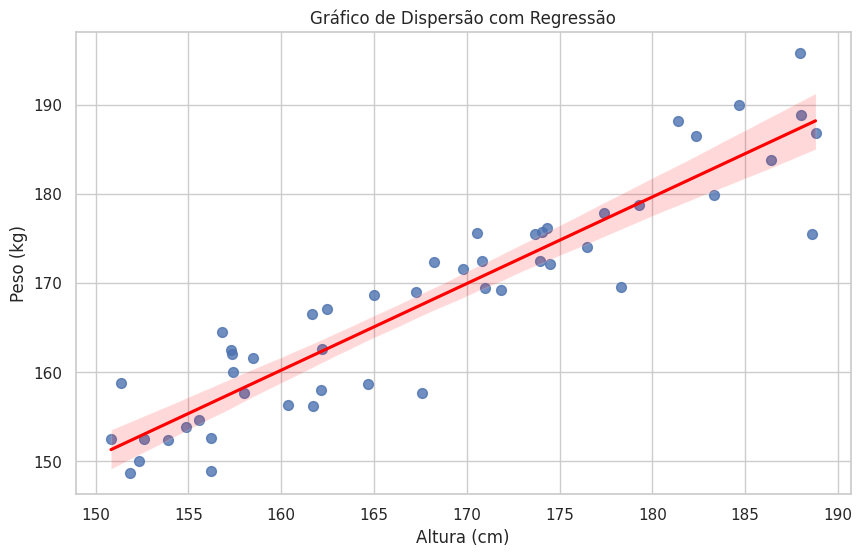

In [12]:
import numpy as np

# Gerando dados fictícios para um gráfico de dispersão com regressão
np.random.seed(42)
altura = np.random.uniform(low=150, high=190, size=50)
peso = altura + np.random.normal(0, 5, size=50)

# Criando um DataFrame
df_scatter = pd.DataFrame({'Altura': altura, 'Peso': peso})

# Criando um gráfico de dispersão com regressão
plt.figure(figsize=(10, 6))
sns.regplot(x='Altura', y='Peso', data=df_scatter, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Gráfico de Dispersão com Regressão')
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.show()


Estudo de Caso: Análise de Desempenho de Vendas em uma Empresa de E-commerce

Contexto:
Uma empresa de e-commerce deseja analisar o desempenho de suas vendas ao longo de um ano para identificar padrões, tendências e áreas de oportunidade. O conjunto de dados contém informações mensais sobre vendas, despesas e principais métricas de desempenho.

In [14]:
import seaborn as sns
import pandas as pd

# Criando dados fictícios
data = {
    'Mes': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
    'Vendas': [50000, 55000, 60000, 75000, 80000, 90000, 110000, 105000, 120000, 130000, 140000, 150000],
    'Despesas': [30000, 32000, 35000, 40000, 42000, 45000, 48000, 50000, 55000, 58000, 60000, 65000],
    'Categoria': ['Eletrônicos', 'Roupas', 'Alimentos', 'Acessórios']*3,
    'Regiao': ['Norte']*4 + ['Sul']*4 + ['Leste']*4
}

# Criando um DataFrame
df = pd.DataFrame(data)

# Visualizando as primeiras linhas do DataFrame
print(df.head())

   Mes  Vendas  Despesas    Categoria Regiao
0  Jan   50000     30000  Eletrônicos  Norte
1  Fev   55000     32000       Roupas  Norte
2  Mar   60000     35000    Alimentos  Norte
3  Abr   75000     40000   Acessórios  Norte
4  Mai   80000     42000  Eletrônicos    Sul


              Vendas      Despesas
count      12.000000     12.000000
mean    97083.333333  46666.666667
std     33942.353091  11372.481406
min     50000.000000  30000.000000
25%     71250.000000  38750.000000
50%     97500.000000  46500.000000
75%    122500.000000  55750.000000
max    150000.000000  65000.000000


<ipython-input-15-8f56ff2ec975>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


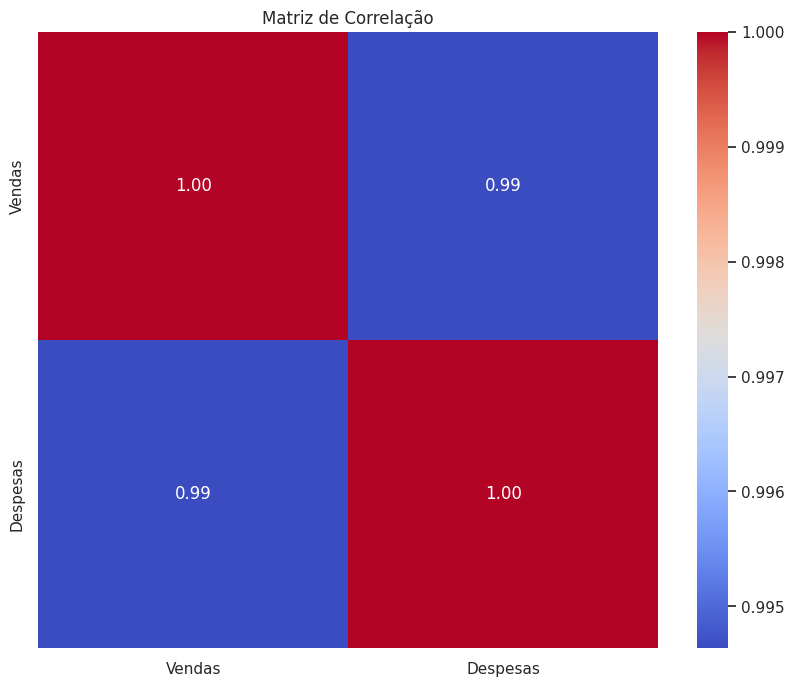

In [15]:
# Resumo estatístico
print(df.describe())

# Correlação entre variáveis
correlation_matrix = df.corr()

# Criando um mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

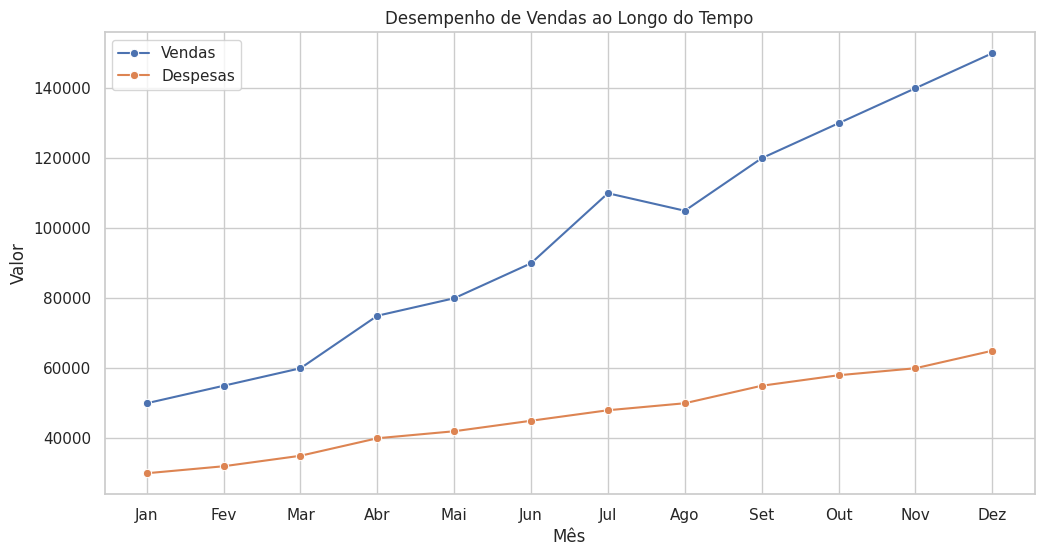

In [16]:
# Gráfico de linhas para vendas ao longo do tempo
plt.figure(figsize=(12, 6))
sns.lineplot(x='Mes', y='Vendas', data=df, marker='o', label='Vendas')
sns.lineplot(x='Mes', y='Despesas', data=df, marker='o', label='Despesas')
plt.title('Desempenho de Vendas ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('Valor')
plt.legend()
plt.show()

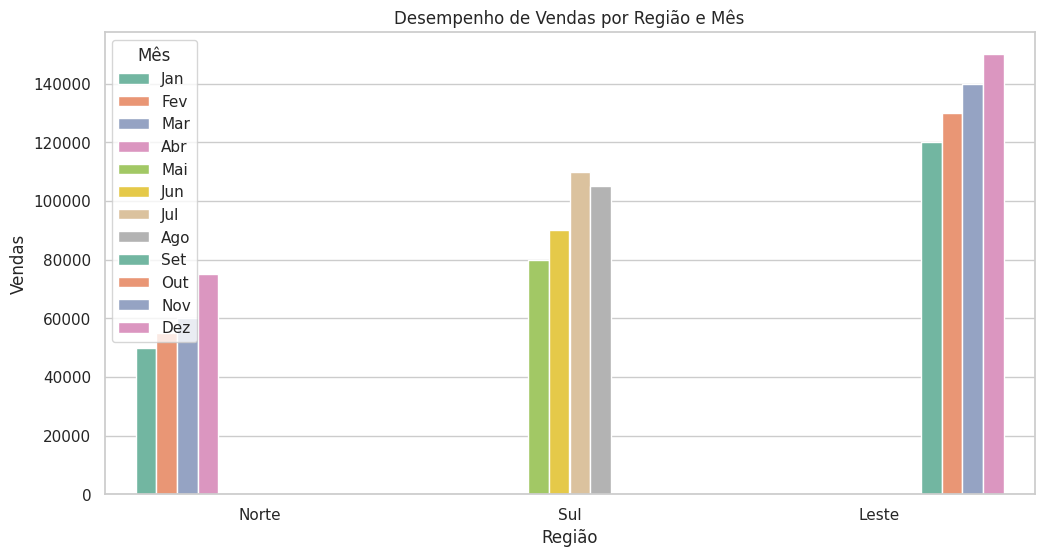

In [18]:
# Gráfico de barras agrupado por região
plt.figure(figsize=(12, 6))
sns.barplot(x='Regiao', y='Vendas', hue='Mes', data=df, palette='Set2')
plt.title('Desempenho de Vendas por Região e Mês')
plt.xlabel('Região')
plt.ylabel('Vendas')
plt.legend(title='Mês')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Criando dados fictícios de clientes
data = {
    'Idade': [25, 30, 35, 22, 28, 32, 45, 50, 48, 60],
    'Renda': [50000, 60000, 75000, 40000, 45000, 55000, 80000, 90000, 95000, 120000],
    'Comprara': [0, 0, 1, 0, 0, 1, 1, 1, 1, 1]  # 0: Não Comprará, 1: Comprará
}

df = pd.DataFrame(data)

# Separando os dados em características (X) e rótulo (y)
X = df[['Idade', 'Renda']]
y = df['Comprara']

# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando um modelo de Random Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
previsoes = modelo.predict(X_test)

# Avaliando o desempenho do modelo
acuracia = accuracy_score(y_test, previsoes)
matriz_confusao = confusion_matrix(y_test, previsoes)
relatorio_classificacao = classification_report(y_test, previsoes)

# Exibindo resultados
print(f'Acurácia do Modelo: {acuracia:.2f}\n')
print('Matriz de Confusão:')
print(matriz_confusao)
print('\nRelatório de Classificação:')
print(relatorio_classificacao)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Criando dados fictícios de clientes
data = {
    'Idade': [25, 30, 35, 22, 28, 32, 45, 50, 48, 60],
    'Renda': [50000, 60000, 75000, 40000, 45000, 55000, 80000, 90000, 95000, 120000],
    'Comprara': [0, 0, 1, 0, 0, 1, 1, 1, 1, 1]  # 0: Não Comprará, 1: Comprará
}

df = pd.DataFrame(data)

# Separando os dados em características (X) e rótulo (y)
X = df[['Idade', 'Renda']]
y = df['Comprara']

# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando um modelo de Random Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
previsoes = modelo.predict(X_test)

# Avaliando o desempenho do modelo
acuracia = accuracy_score(y_test, previsoes)
matriz_confusao = confusion_matrix(y_test, previsoes)
relatorio_classificacao = classification_report(y_test, previsoes)

# Exibindo resultados
print(f'Acurácia do Modelo: {acuracia:.2f}\n')
print('Matriz de Confusão:')
print(matriz_confusao)
print('\nRelatório de Classificação:')
print(relatorio_classificacao)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Criando dados fictícios de vendas ao longo do tempo
np.random.seed(42)
meses = pd.date_range(start='2023-01-01', periods=24, freq='M')
vendas = np.random.randint(80000, 120000, size=24) + np.arange(24) * 2000

df = pd.DataFrame({'Mes': meses, 'Vendas': vendas})

# Criando características adicionais, como o mês em formato numérico
df['MesNumerico'] = df['Mes'].dt.month
df['Ano'] = df['Mes'].dt.year

# Separando os dados em características (X) e rótulo (y)
X = df[['MesNumerico', 'Ano']]
y = df['Vendas']

# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando um modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
previsoes = modelo.predict(X_test)

# Avaliando o desempenho do modelo
erro_medio_quadratico = mean_squared_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

# Exibindo resultados
print(f'Erro Médio Quadrático: {erro_medio_quadratico:.2f}')
print(f'R² (Coeficiente de Determinação): {r2:.2f}')

# Visualizando as previsões em relação aos dados reais
plt.figure(figsize=(10, 6))
plt.scatter(df['Mes'], df['Vendas'], label='Dados Reais', color='blue')
plt.plot(df['Mes'], modelo.predict(df[['MesNumerico', 'Ano']]), label='Previsões', color='red')
plt.title('Previsão de Vendas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Criando dados fictícios de vendas ao longo do tempo
np.random.seed(42)
meses = pd.date_range(start='2023-01-01', periods=24, freq='M')
vendas = np.random.randint(80000, 120000, size=24) + np.arange(24) * 2000

df = pd.DataFrame({'Mes': meses, 'Vendas': vendas})

# Criando características adicionais, como o mês em formato numérico
df['MesNumerico'] = df['Mes'].dt.month
df['Ano'] = df['Mes'].dt.year

# Separando os dados em características (X) e rótulo (y)
X = df[['MesNumerico', 'Ano']]
y = df['Vendas']

# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criando e treinando uma rede neural simples
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Camada de saída para prever vendas
])

modelo.compile(optimizer='adam', loss='mean_squared_error')

# Treinando o modelo
modelo.fit(X_train_scaled, y_train, epochs=100, batch_size=8, verbose=0)

# Avaliando o desempenho do modelo no conjunto de teste
erro_medio_quadratico = modelo.evaluate(X_test_scaled, y_test)
print(f'Erro Médio Quadrático: {erro_medio_quadratico:.2f}')

# Visualizando as previsões em relação aos dados reais
previsoes = modelo.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(df['Mes'], df['Vendas'], label='Dados Reais', color='blue')
plt.plot(df['Mes'].iloc[X_test.index], previsoes, label='Previsões', color='red')
plt.title('Previsão de Vendas ao Longo do Tempo (Rede Neural)')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.show()